# Clickable Fixation Duration Topoplot Prototype

This notebook builds a clickable fixation `duration` topoplot with dummy class probabilities derived from ERP-image heuristics.

- fixation dataset only
- inference / topoplot only for `sort_variable == duration`
- no model training in the prototype path
- scoring on unseen duration channels from the additional task file when possible, otherwise on a held-out labelled channel split
- topoplot uses dummy `p(pattern)` / `p(no class)` values from ERP-image features
- clicking a channel opens the corresponding unseen duration ERP image
- the ERP image keeps the asymmetric zero-anchored colorbar from `notebooks/utils/erp_image_utils.jl`


In [1]:
import Pkg

week15_dir = if isfile(joinpath(pwd(), "topoplots.ipynb")) && isfile(joinpath(pwd(), "..", "model_test", "Project.toml"))
    pwd()
else
    candidate = joinpath(pwd(), "notebooks", "week_15")
    @assert isfile(joinpath(candidate, "topoplots.ipynb")) "Could not locate notebooks/week_15 from current working directory."
    candidate
end

model_test_dir = normpath(joinpath(week15_dir, "..", "model_test"))
cd(week15_dir)
Pkg.activate(model_test_dir)

if !isdefined(Main, :Week15TryNewData)
    include(joinpath(week15_dir, "try_new_data_helpers.jl"))
end
if !isdefined(Main, :TestOutputLayerHelpers)
    include(joinpath(week15_dir, "..", "model_test", "test_outputlayer_helpers.jl"))
end
if !isdefined(Main, :Week15Topoplots)
    include(joinpath(week15_dir, "topoplots_helpers.jl"))
end

using .Week15Topoplots
using DataFrames

backend = Week15Topoplots.activate_topoplot_backend!()

if backend == :WGLMakie
    wglmakie = Base.invokelatest(getfield, Week15Topoplots, :WGLMakie)
    bonito = getfield(wglmakie, :Bonito)
    page_reset = getfield(bonito, :Page)
    Base.invokelatest(page_reset)
end

println("Week-15 directory: ", week15_dir)
println("Active project: ", Base.active_project())
println("Makie backend: ", backend)
nothing


  Activating project at `~/Dokumente/BA2/notebooks/model_test`


Week-15 directory: /home/benjamin/Dokumente/BA2/notebooks/week_15
Active project: /home/benjamin/Dokumente/BA2/notebooks/model_test/Project.toml
Makie backend: WGLMakie


## Usage

Run the next cell once. It will:

1. load the fixation `duration` ERP images,
2. build dummy class probabilities from image heuristics,
3. score up to 64 unseen duration channels with dummy `p(pattern)` and `p(no class)`.

If the additional duration task file contains no truly unseen channels anymore, the helper automatically falls back to a held-out channel split from the labelled duration set.

The first run can still take a moment because Makie and the helper modules may precompile.


In [2]:
using DataFrames

data_split_seed = nothing  # set an Int for reproducible runs; `nothing` uses time_ns()
score_mode = :dummy

ctx = Week15Topoplots.build_fixation_duration_topoplot_context(
    target_size = (64, 64),
    lowpass = true,
    max_inference_channels = 64,
    data_split_seed = data_split_seed,
    score_mode = score_mode,
)

summary_df = ctx.model_summary_df
top_channels_df = first(
    sort(
        select(
            ctx.score_df,
            :channel,
            :channel_name,
            :prob_pattern,
            :prob_no_pattern,
            :pattern_margin,
            :predicted_label,
        ),
        :prob_pattern;
        rev = true,
    ),
    12,
)

display(summary_df)
display(top_channels_df)
nothing


Row,metric,value
,String,Any
1,score_mode,dummy
2,duration_label_rows,84
3,duration_label_channels,84
4,unseen_duration_channels,64
5,inference_split_images_total,256
6,dummy_pattern_bias,-0.1
7,dummy_logit_temperature,3.0
8,dummy_probability_span,0.2
9,dummy_feature_weights,peak_trend_abs=+1.15 | peak_span=+0.90 | diag_advantage=+0.80 | late_energy_shift=+0.55 | row_energy_flatness=-0.45


Row,channel,channel_name,prob_pattern,prob_no_pattern,pattern_margin,predicted_label
,Int64,String,Float64,Float64,Float64,String
1,67,ch067,0.692624,0.307376,0.385248,pattern
2,12,ch012,0.684701,0.315299,0.369402,pattern
3,69,ch069,0.661448,0.338552,0.322895,pattern
4,43,ch043,0.657836,0.342164,0.315673,pattern
5,19,ch019,0.657394,0.342606,0.314787,pattern
6,17,ch017,0.656386,0.343614,0.312772,pattern
7,53,ch053,0.654928,0.345072,0.309857,pattern
8,71,ch071,0.651987,0.348013,0.303975,pattern
9,57,ch057,0.651802,0.348198,0.303603,pattern


In [3]:
# Bonito/WGLMakie app: in VS Code this can render in the Plot Pane even when inline notebook output stays blank.
interactive = Week15Topoplots.build_fixation_duration_topoplot_app(ctx)
display(interactive.app)
nothing


Bonito.App(Bonito.var"#30#31"{Makie.Figure}(Scene(5 children, 0 plots)), Base.RefValue{Union{Nothing, Bonito.Session}}(nothing), "Fixation duration topoplot", nothing)

In [4]:
# Browser fallback for notebook frontends where inline WGLMakie stays blank.
# This should open the interactive Bonito app in your default browser.
interactive_browser = Week15Topoplots.display_fixation_duration_topoplot!(ctx; target = :browser)
nothing


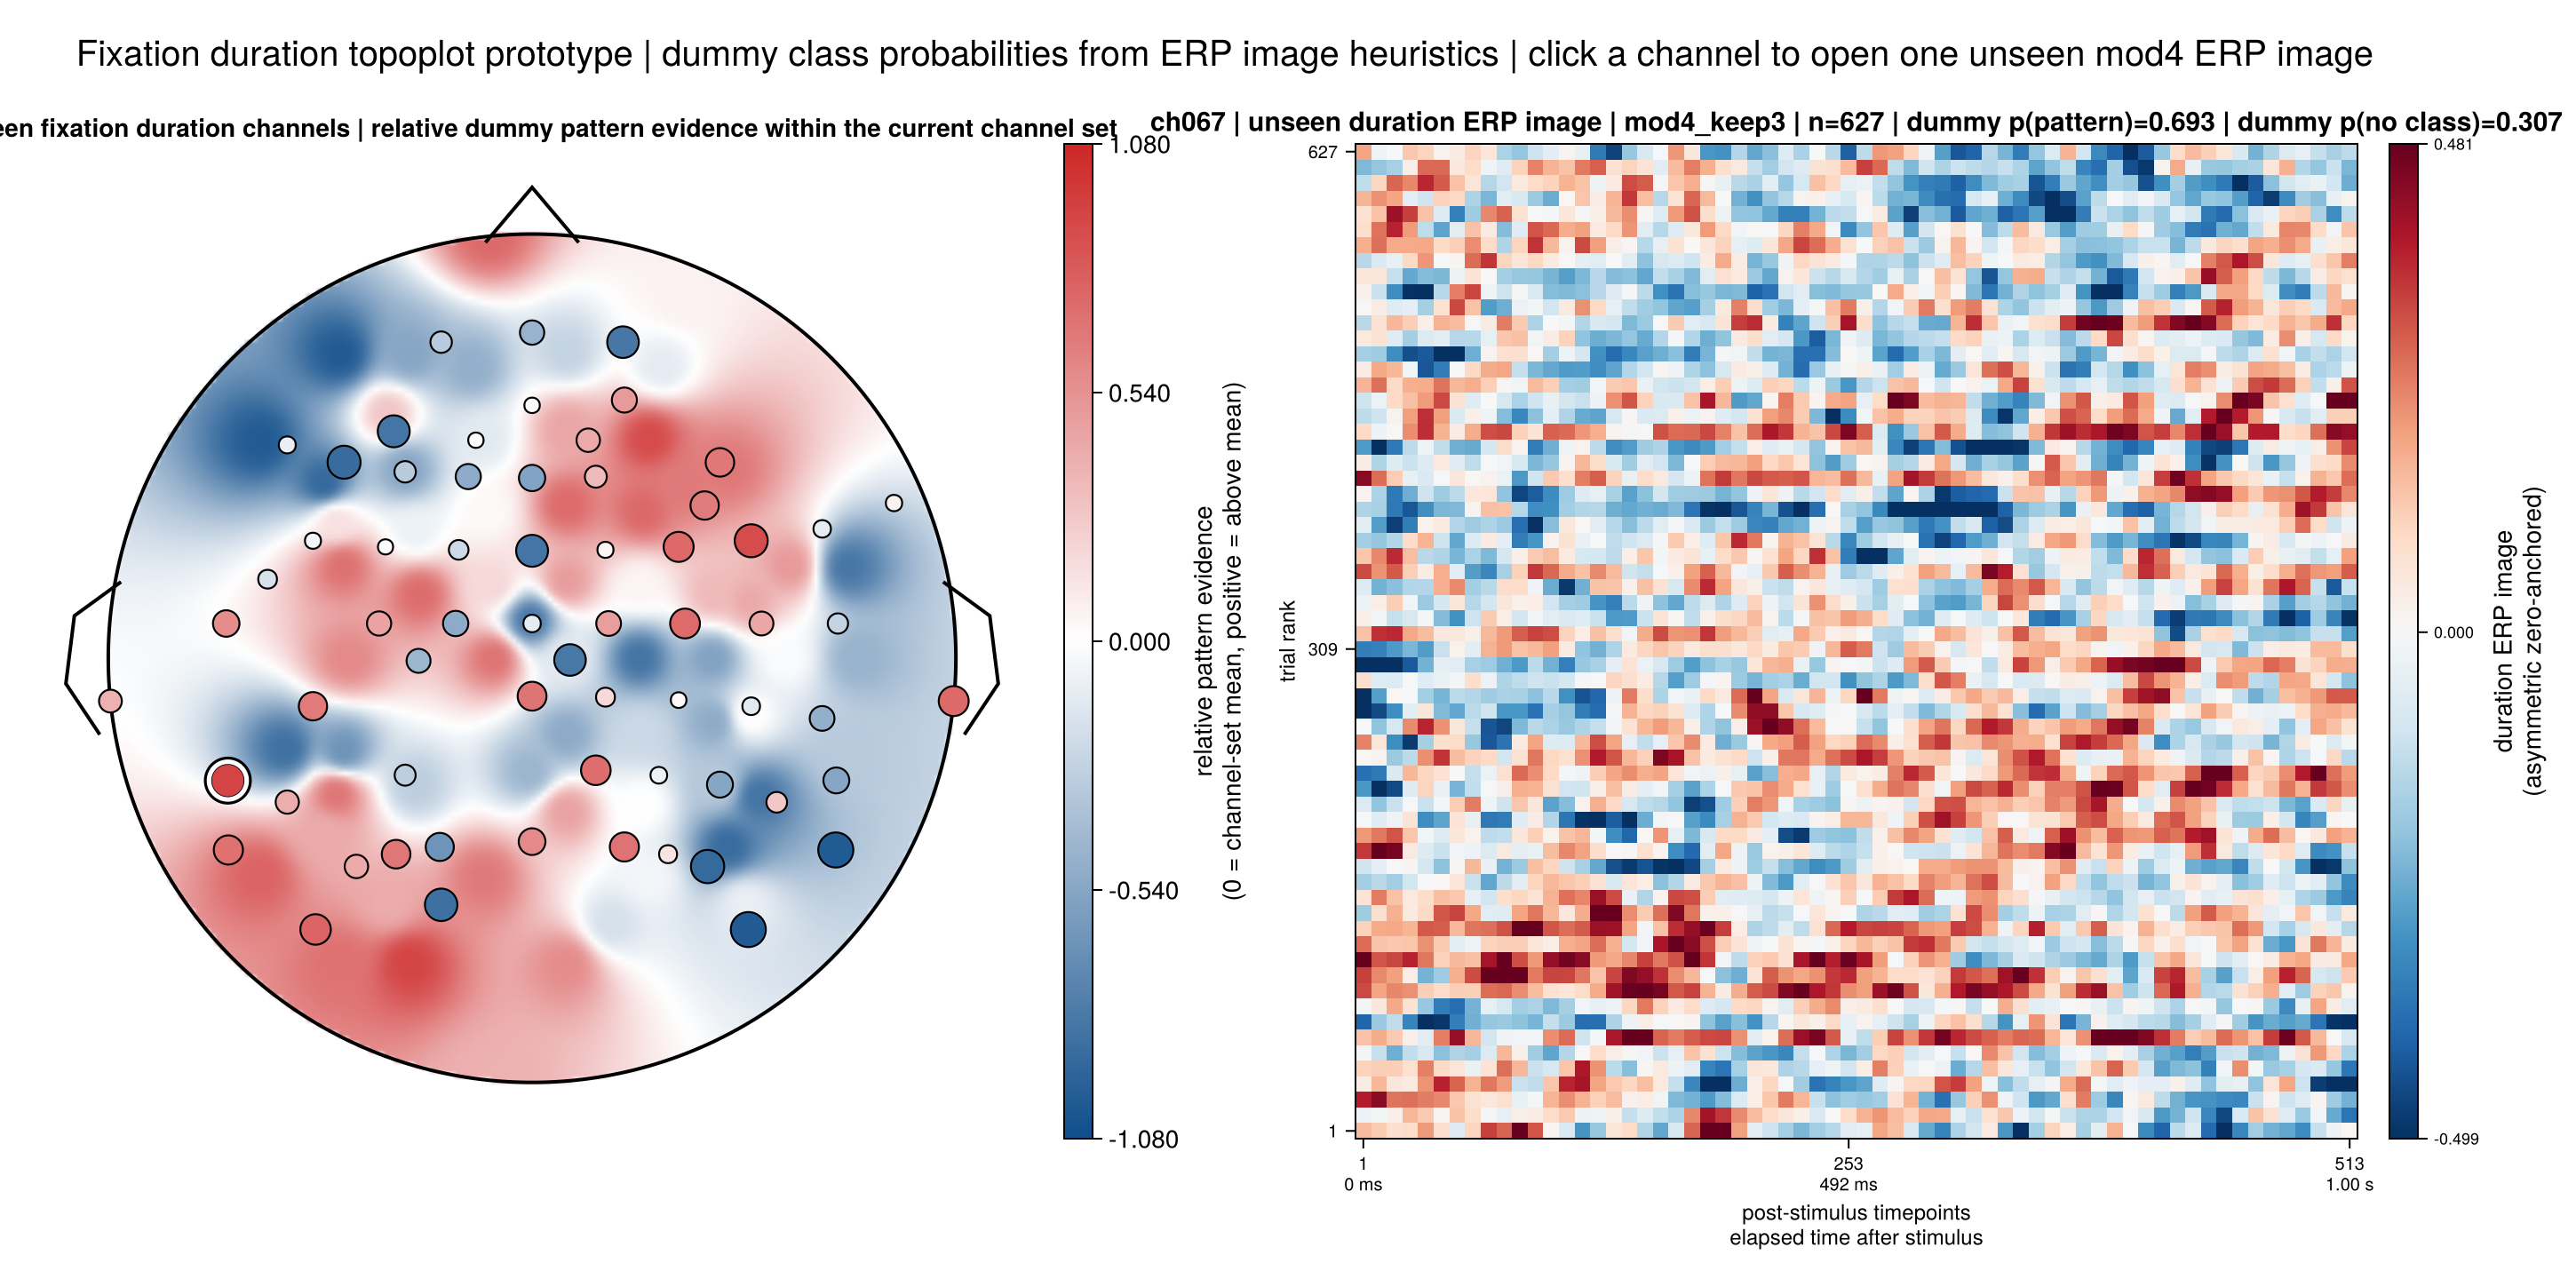

In [5]:
# Static fallback when browser/plot-pane interaction is unavailable.
import CairoMakie
CairoMakie.activate!()
topo_static = Week15Topoplots.plot_fixation_duration_topoplot(ctx)
display(topo_static.figure)
nothing
